# <font color="pink"> Tutorial Network 1


En este cuadero se describe la solucion de tres problemas de redes:
**arbol de expansion minima,ruta mas corta,flujo maximo**
Este tutoial esta basado en la documentacion de:
[Networkx](https://network.org/en/)

In [ ]:
import network as nx
import matplotlib.pyplot as plt


### <span style="font-family: 'Century Gothic', sans-serif; color: #8E44AD; font-weight: bold;">Algoritmo de árbol de expansión mínima</span>
Sea $N = \{1, 2, \dots, n\}$ el conjunto de nodos de la red.

Definimos:
\begin{align*}
C_k &= \{ \text{Conjunto de nodos conectados de forma permanente en la iteración } k \} \\
\overline{C}_k &= \{ \text{Conjunto de nodos que todavía se deben conectar de forma permanente} \}
\end{align*}

**Paso 0:** $C_0 = \phi \quad ; \quad \overline{C}_0 = N$

**Paso 1:** Comenzar con cualquier nodo en $\overline{C}_0$ y hacer $C_1 = \{i\}$, $\overline{C}_1 = N - \{i\}$. Hacer $k = 2$.

**Paso general $k$:** Seleccionar un nodo $j^*$ en el conjunto no conectado $\overline{C}_{k-1}$ que produzca el arco más corto a un nodo conectado en el conjunto $C_{k-1}$.

Enlazar a $j^*$ en forma permanente con $C_{k-1}$ y sacarlo de $\overline{C}_{k-1}$, es decir:
$$C_k = C_{k-1} + \{j^*\} \qquad \overline{C}_k = \overline{C}_{k-1} - \{j^*\}$$

Si $\overline{C}_k = \phi$, Detenerse.

Otro caso: hacer $k = k + 1$ y repetir el Paso $k$.

Se utilizo el algoritmo de árbol de expansión mínima que se encuentra la documentacion de:
[Networkx](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.tree.mst.minimum_spanning_tree.html)


**minimum_spanning_tree ( G , weight = 'weight' , algorithm = 'kruskal' , ignore_nan = False )**
Devuelve un árbol o bosque de expansión mínima en un grafo no dirigido G.


*Resolviendo el ejercicio con dicho algortimo,obtenemos que:*
**El árbol de de expansión mínima se muestra en color verde,tiene una <span style="color: red; font-weight: bold;">distancia total de 1+2+1+3+4+2=13**</span>



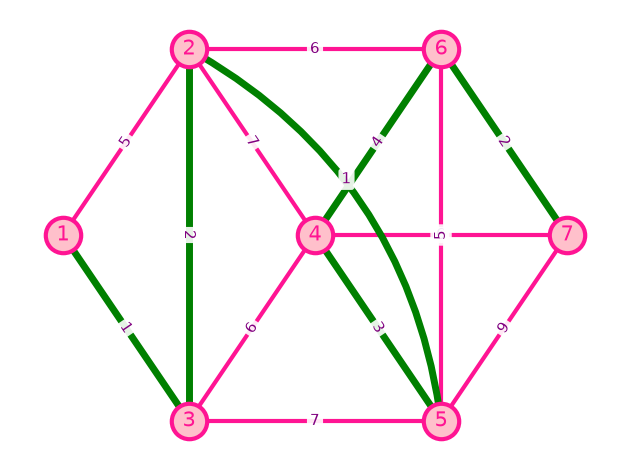

In [25]:
# Creación del grafo no dirigido 
G = nx.Graph()
G.add_edges_from([#se agregan las aristas con las "distancias"
    (1, 2, {"weight": 5}),
    (1, 3, {"weight": 1}),
    (3, 2, {"weight": 2}),
    (3, 4, {"weight": 6}),  
    (3, 5, {"weight": 7}),
    (2, 6, {"weight": 6}),  
    (2, 5, {"weight": 1}),
    (2, 4, {"weight": 7}),
    (4, 6, {"weight": 4}),
    (4, 7, {"weight": 6}),
    (5, 4, {"weight": 3}),
    (5, 6, {"weight": 5}),
    (5, 7, {"weight": 9}),
    (6, 7, {"weight": 2}),
])

#Distribucion de los nodos con coordenadas
pos = {
    1: (0.0, 0.0),
    2: (2.0, 2.0),
    3: (2.0, -2.0),
    4: (4.0, 0.0),
    5: (6.0, -2.0),
    6: (6.0, 2.0),
    7: (8.0, 0.0),
}

# aristas rectas y arista curva
# Curva (2, 5) para no atravesar el nodo central 4
curved_edges = [(2, 5)]
straight_edges = [
    e
    for e in G.edges()
    if e not in curved_edges and (e[1], e[0]) not in curved_edges
]

# dibujo de las aristas 
nx.draw_networkx_edges(
    G, pos, edgelist=straight_edges, edge_color="deeppink", width=3, arrows=False
)
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=curved_edges,
    edge_color="deeppink",
    width=3,
    arrows=True,
    arrowstyle="-",
    connectionstyle="arc3,rad=-0.25",
)

# algortimo que encuentra el arbol de expansion
T = nx.minimum_spanning_tree(G)
t_straight = [
    e for e in T.edges() if e in straight_edges or (e[1], e[0]) in straight_edges
]
t_curved = [
    e for e in T.edges() if e in curved_edges or (e[1], e[0]) in curved_edges
]

# aristas del Árbol de Expansión Mínima (MST) en verde
nx.draw_networkx_edges(
    T, pos, edgelist=t_straight, edge_color="green", width=5, arrows=False
)
# Aristas curvas del MST (si aplica)
if t_curved:
    nx.draw_networkx_edges(
        T,
        pos,
        edgelist=t_curved,
        edge_color="green",
        width=5,
        arrows=True,
        arrowstyle="-",
        connectionstyle="arc3,rad=-0.25",
    )

#dibujo de nodos y sus etiquetas
nx.draw_networkx_nodes(
    G, pos, node_color="pink", node_size=650, edgecolors="deeppink", linewidths=3
)
nx.draw_networkx_labels(
    G, pos, font_size=15, font_family="sans-serif", font_color="deeppink"
)

#etiquetas de las distancias sobre aristas rectas
edge_labels = {
    (u, v): d["weight"]
    for u, v, d in G.edges(data=True)
    if (u, v) not in curved_edges and (v, u) not in curved_edges
}
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=11,
    font_color="purple",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9),
)

# agregando la distancia de la arista curva (2, 5)
plt.text(
    4.5,
    0.6,
    "1",
    fontsize=11,
    color="purple",
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9),
)


plt.axis("off")
plt.tight_layout()
plt.show()#muestra la figura

### <span style="font-family: 'Century Gothic', sans-serif; color: #8E44AD; font-weight: bold;">Problema de la ruta más corta</span>
<p style="text-align: justify;">

Se considera una red conexa y no dirigida con dos nodos especiales, llamados origen y destino. A cada ligadura se asocia una distancia no negativa. El objetivo es encontrar la ruta más corta —la trayectoria de mínima distancia total— del origen al destino.</p>

**Algoritmo**

**Objetivo de la $n$-ésima iteración:**<p style="text-align: justify;"> Encontrar el $n$-ésimo nodo más cercano al origen. Repetir para $n = 1, 2, \dots$ hasta que el $n$-ésimo nodo más cercano sea el destino..</p>

**Datos de la $n$-ésima iteración:** <p style="text-align: justify;">$n-1$ nodos más cercanos al origen -encontrados en iteraciones previas—, incluida su ruta más corta y la distancia desde el origen (estos son nodos resueltos; el resto son nodos no resueltos).
</p>

**Candidato a $n$-ésimo nodo más cercano:** <p style="text-align: justify;">Cada nodo no resuelto con conexión directa a uno o más nodos resueltos. Tomar el nodo no resuelto que tiene la ligadura más corta (los empates proporcionan candidatos adicionales).
</p>



Se utilizo el algoritmo de Shortest Paths que se encuentra la documentacion de:
[Networkx](https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html)


**shortest_path(G[, source, target, weight, ...])**
(calcula los caminos más cortos en el grafo)

Este funciona con grafos dirigidos y no dirigidos.


*Resolviendo el ejercicio con dicho algortimo,obtenemos que:*

**Ruta más corta:**<span style="color: red; font-weight: bold;"> $1 \rightarrow 3 \rightarrow 2 \rightarrow 6 \rightarrow 7$  </span>

**Distancia total:** <span style="color: red; font-weight: bold;">$11$</span>


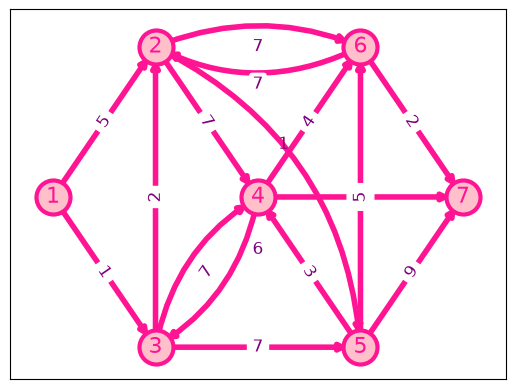

Ruta más corta: [1, 3, 2, 6, 7]
Distancia total: 11


In [18]:
G = nx.DiGraph()
G.add_edges_from([#se agregan las aristas con las "distancias"
    (1, 2, {"weight": 5}),
    (1, 3, {"weight": 1}),
    (3, 2, {"weight": 2}),
    (3, 4, {"weight": 6}),
    (3, 5, {"weight": 7}),
    (2, 6, {"weight": 6}),
    (2, 5, {"weight": 1}),
    (2, 4, {"weight": 7}),
    (2, 6, {"weight": 6}),
    (4, 6, {"weight": 4}),
    (4, 3, {"weight": 7}),
    (4, 7, {"weight": 6}),
    (5, 4, {"weight": 3}),
    (5, 6, {"weight": 5}),
    (5, 7, {"weight": 9}),
    (6, 7, {"weight": 2}),
    (6, 2, {"weight": 7})
])
#Distribucion de los nodos con coordenadas
pos = {
    1: (0.0, 0.0),
    2: (2.0, 2.0),
    3: (2.0, -2.0),
    4: (4.0, 0.0),
    5: (6.0, -2.0),
    6: (6.0, 2.0),
    7: (8.0, 0.0),
}





# 1. Nodos y etiquetas
nx.draw_networkx_nodes(G, pos, node_color="pink", node_size=600, edgecolors="deeppink", linewidths=3)#diseño de las aristas
nx.draw_networkx_labels(G, pos, font_size=16, font_family="sans-serif", font_color="deeppink")#dibujar etiquetas

#  Aristas rectas 
curved_pairs = [(2, 6),(6,2), (3, 4),(4,3), (2, 5)]
straight_edges = [e for e in G.edges() if e not in curved_pairs and (e[1], e[0]) not in curved_pairs]
#diseño de las aristas
nx.draw_networkx_edges(
    G, pos,
    edgelist=straight_edges,
    edge_color="deeppink",
    width=4,
    
)

# aristas curvas
nx.draw_networkx_edges(
    G, pos,
    edgelist=[(2, 6)],
    edge_color="deeppink",
    width=4,
    arrows=True,
    arrowstyle='->',
    connectionstyle="arc3,rad=-0.2"
)
nx.draw_networkx_edges(
    G, pos,
    edgelist=[(6, 2)],
    edge_color="deeppink",
    width=4,
    arrows=True,
    arrowstyle='->',
    connectionstyle="arc3,rad=-.25"
)


nx.draw_networkx_edges(
    G, pos,
    edgelist=[(2, 5)],
    edge_color="deeppink",
    width=4,
    arrows=True,
    arrowstyle='->',
    connectionstyle="arc3,rad=-.28",
    
)
nx.draw_networkx_edges(
    G, pos,
    edgelist=[(3, 4)],
    edge_color="deeppink",
    width=4,
    arrows=True,
    arrowstyle='->',
    connectionstyle="arc3,rad=-0.22"
)
nx.draw_networkx_edges(
    G, pos,
    edgelist=[(4, 3)],
    edge_color="deeppink",
    width=4,
    arrows=True,
    arrowstyle='->',
    connectionstyle="arc3,rad=-0.22"
)

# Colocamos el valor "1","7","6"
plt.text(
    4.5, 0.7, "1",
    fontsize=12,
    color="purple",
    ha="center",
    va="center",
   
)
plt.text(
    4, 1.5, "7",
    fontsize=12,
    color="purple",
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=1)
)

plt.text(
    4, -0.7, "6",
    fontsize=12,
    color="purple",
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=1)
)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(#dibujar etiquetas de bordes
    G, pos,
    edge_labels=edge_labels,
    font_size=12,
    font_color="purple",
    label_pos=0.5,
    verticalalignment='center'
    

    
)




plt.show()#muestra la figura
print("Ruta más corta:",nx.shortest_path(G, source=1, target=7,weight='weight'))
print("Distancia total:",nx.shortest_path_length(G, source=1, target=7,weight='weight'))

<p style="text-align: justify;">

### <span style="font-family: 'Century Gothic', sans-serif; color: #8E44AD; font-weight: bold;">Problemas del flujo máximo</span>

**Algoritmo:**

1. Identificar una trayectoria de aumento (si no existe una, los flujos netos asignados constituyen un patrón de flujo óptimo).

2. Identificar la capacidad residual $c^*$ de esta trayectoria. Se aumenta en $c^*$ el flujo de esta trayectoria.

3. Se disminuye en $c^*$ la capacidad residual de cada arco en esta trayectoria de aumento. Se aumenta en $c^*$ la capacidad residual de cada arco en la dirección opuesta en esta trayectoria.

Regresar al paso 1.





Se utilizo el algoritmo de maximum_flow que se encuentra la documentacion de:
[Networkx](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.flow.maximum_flow.html)


maximum_flow(flowG, _s, _t, capacity='capacity', flow_func=None, **kwargs)[source]
(Encontra el flujo máximo de una sola mercancía.)



*Resolviendo el ejercicio con dicho algortimo,obtenemos que el*

**Flujo máximo:** =<span style="color: red; font-weight: bold;">$20$</span>

</div>

https://www.google.com/search?q=ruta+mas+cortanetwork+pythn+Seervada+Park&oq=ruta+mas+cortanetwork+pythn+Seervada+Park&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIJCAEQIRgKGKABMgkIAhAhGAoYoAHSAQkxMTEyN2owajeoAgCwAgA&sourceid=chrome&source=chrome.ob&ie=UTF-8


https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_networkx_edge_labels.html#networkx.drawing.nx_pylab.draw_networkx_edge_labels

In [ ]:
https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.flow.maximum_flow.html


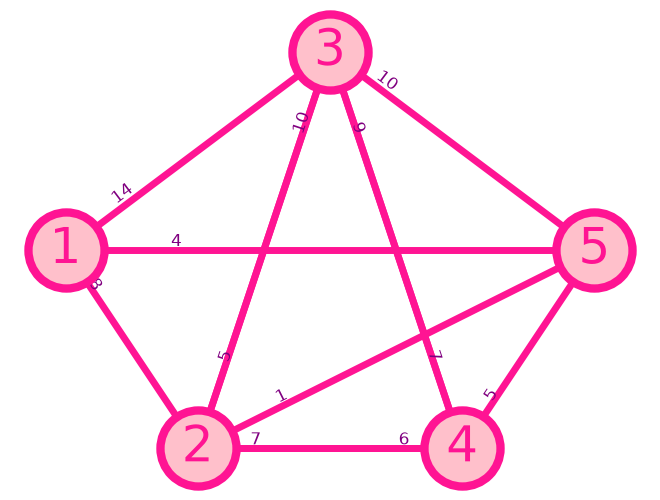

Flujo máximo: 20
{1: {3: 8, 5: 4, 2: 8}, 3: {2: 0, 4: 3, 5: 10}, 5: {}, 2: {3: 5, 5: 1, 4: 2}, 4: {2: 0, 3: 0, 5: 5}}


In [13]:
G = nx.DiGraph()#Creacion del grafo
G.add_edge(1, 3, capacity=14)##se agregan las aristas con las "capacidades"
G.add_edge(1, 5, capacity=4)
G.add_edge(1, 2, capacity=8)
G.add_edge(2, 3, capacity=5)
G.add_edge(2, 5, capacity=1)
G.add_edge(2, 4, capacity=7)
G.add_edge(3, 2, capacity=10)
G.add_edge(3, 4, capacity=9)  
G.add_edge(3, 5, capacity=10)
G.add_edge(4, 2, capacity=6)
G.add_edge(4, 3, capacity=7)
G.add_edge(4, 5, capacity=5)
##Distribucion de los nodos con coordenadas
pos = {1: (0, 0), 2: (2, -2), 3: (4, 2), 4: (6, -2), 5: (8, 0)}

options = {#estilos que se aplicaran al grafo
    "font_size": 36,
    "node_size": 3000,
    "node_color": "pink",
    "edgecolors": "deeppink",
    "linewidths": 6,
    "width": 5,
    "edge_color": "deeppink",#agrega color a la arist
    "font_color": "deeppink",#agrega color a los 
    "arrows": False
    
}
## Dibuja el grafo G con las posiciones 'pos', mostrando etiquetas y aplicando los estilos
nx.draw(G, pos, with_labels=True, **options)


labels = nx.get_edge_attributes(G, "capacity")# Extrae la capacidad de cada arista
## Dibuja los valores de capacidad sobre las aristas
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels,verticalalignment='bottom',label_pos=0.2, font_size=12,font_color="purple",bbox=dict(boxstyle="square", alpha=0))


plt.show()#muestra la figura
flow_value,flow_dict=nx.maximum_flow(G,1,5)## Calcula el flujo máximo desde el nodo origen (1) hasta el nodo destino (5)
print("Flujo máximo:",flow_value)# Valor total del flujo máximo alcanzado
print(flow_dict)# Diccionario con el flujo asignado a cada arista